# Customer Review Score Drivers Analysis

**Business question:** What drives 1-star reviews — delivery performance, specific product categories, or both?

**Decisions supported:**
- Prioritisation of operational vs. product quality improvements for review score uplift
- Seller governance and product category exit criteria
- Customer satisfaction intervention timing


## Data Sources

| Query | Description | Grain |
|---|---|---|
| Q1: Score distribution | `order_reviews` | One row per review score (1–5) |
| Q2: Score by delivery status | `order_reviews` + `vw_delivery_sla_metrics` | One row per delivery status (On-Time / Delayed) |
| Q3: Bottom 10 categories | `order_reviews` + `vw_item_fact` + `vw_delivery_sla_metrics` | One row per product category (min 50 orders) |

**Key columns used:** `review_score`, `total_reviews`, `pct_of_total`, `delivery_status`, `avg_review_score`, `category_english`, `total_orders`

**Filter:** Q3 applies a minimum of 50 orders per category to exclude categories with insufficient volume for stable average score calculation.


In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display

_REPO_ROOT = Path().resolve().parents[1]
if str(_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT))

from analysis.utils.db import get_connection
from analysis.utils.sql_loader import get_sql_path, load_queries
from analysis.utils.plotting import apply_style, save_figure

apply_style()

# Load SQL queries
sql_path = get_sql_path("sql/analysis/04_review_score_drivers.sql")
queries = load_queries(sql_path)

# Execute all three review-score queries
with get_connection() as conn:
    df_score_dist       = pd.read_sql(queries[0], conn)
    df_delivery_scores  = pd.read_sql(queries[1], conn)
    df_worst_categories = pd.read_sql(queries[2], conn)

_checks_04 = [
    ("Score dist rows > 0",               len(df_score_dist) > 0),
    ("Delivery score rows > 0",           len(df_delivery_scores) > 0),
    ("Worst category rows > 0",           len(df_worst_categories) > 0),
    ("Review scores in 1-5 range",        df_score_dist["review_score"].between(1, 5).all()),
    ("pct_of_total sums to ~100",         abs(df_score_dist["pct_of_total"].sum() - 100) < 1),
]
print("Notebook 04 — Data Validation")
for label, passed in _checks_04:
    print(f"  [{'PASS' if passed else 'FAIL'}]  {label}")

print()
display(df_score_dist)
display(df_delivery_scores)
display(df_worst_categories)


/var/folders/f2/83l3tcxd02d7x40w9_lwqz5m0000gn/T/ipykernel_61433/3611329702.py:25: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_score_dist       = pd.read_sql(queries[0], conn)
/var/folders/f2/83l3tcxd02d7x40w9_lwqz5m0000gn/T/ipykernel_61433/3611329702.py:26: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_delivery_scores  = pd.read_sql(queries[1], conn)
/var/folders/f2/83l3tcxd02d7x40w9_lwqz5m0000gn/T/ipykernel_61433/3611329702.py:27: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_worst_categories = pd.read_sql(quer

Notebook 04 — Data Validation
  [PASS]  Score dist rows > 0
  [PASS]  Delivery score rows > 0
  [PASS]  Worst category rows > 0
  [PASS]  Review scores in 1-5 range
  [PASS]  pct_of_total sums to ~100



,review_score,total_reviews,pct_of_total
0,5,57328,57.78
1,4,19142,19.29
2,3,8179,8.24
3,2,3151,3.18
4,1,11424,11.51


,delivery_status,total_reviews,avg_review_score
0,Delayed,7700,2.566494
1,On-Time,88661,4.293737


,category_english,total_orders,avg_review_score
0,office_furniture,1263,3.616390
1,fashion_male_clothing,111,3.702703
2,audio,347,3.834294
3,construction_tools_safety,166,3.849398
4,home_confort,395,3.863291
5,fixed_telephony,214,3.901869
6,fashion_underwear_beach,120,3.933333
7,home_construction,487,3.967146
8,bed_bath_table,9313,3.970740
9,telephony,4168,4.003119


## Analytical Methodology

**Methods applied:**
- **Colour-coded bar chart** (panel A): each score value (1–5) is assigned a semantic colour from red to green. Percentage labels above each bar allow immediate comparison without relying on axis reading.
- **Grouped bar chart** (panel B): two bars (On-Time, Delayed) with a gap annotation showing the score differential. This isolates the delivery effect on review score as a single, quantifiable number.
- **KPI scorecard** (panel C): scalar summary of review KPIs for executive context before the category-level detail.
- **3-tier colour horizontal bar** (panel D): three colours encode criticality — red (< 3.5), amber (3.5–4.0), green (≥ 4.0) — against a reference line at score = 4.0. Bar labels show both the score and the order volume, preventing misinterpretation of low scores from small samples.

**Why this method:** The analytical question has two parts — overall score distribution and causal drivers. Separating these into distinct panels (A for distribution, B for delivery effect, D for category effect) prevents conflation and allows each driver to be evaluated independently.


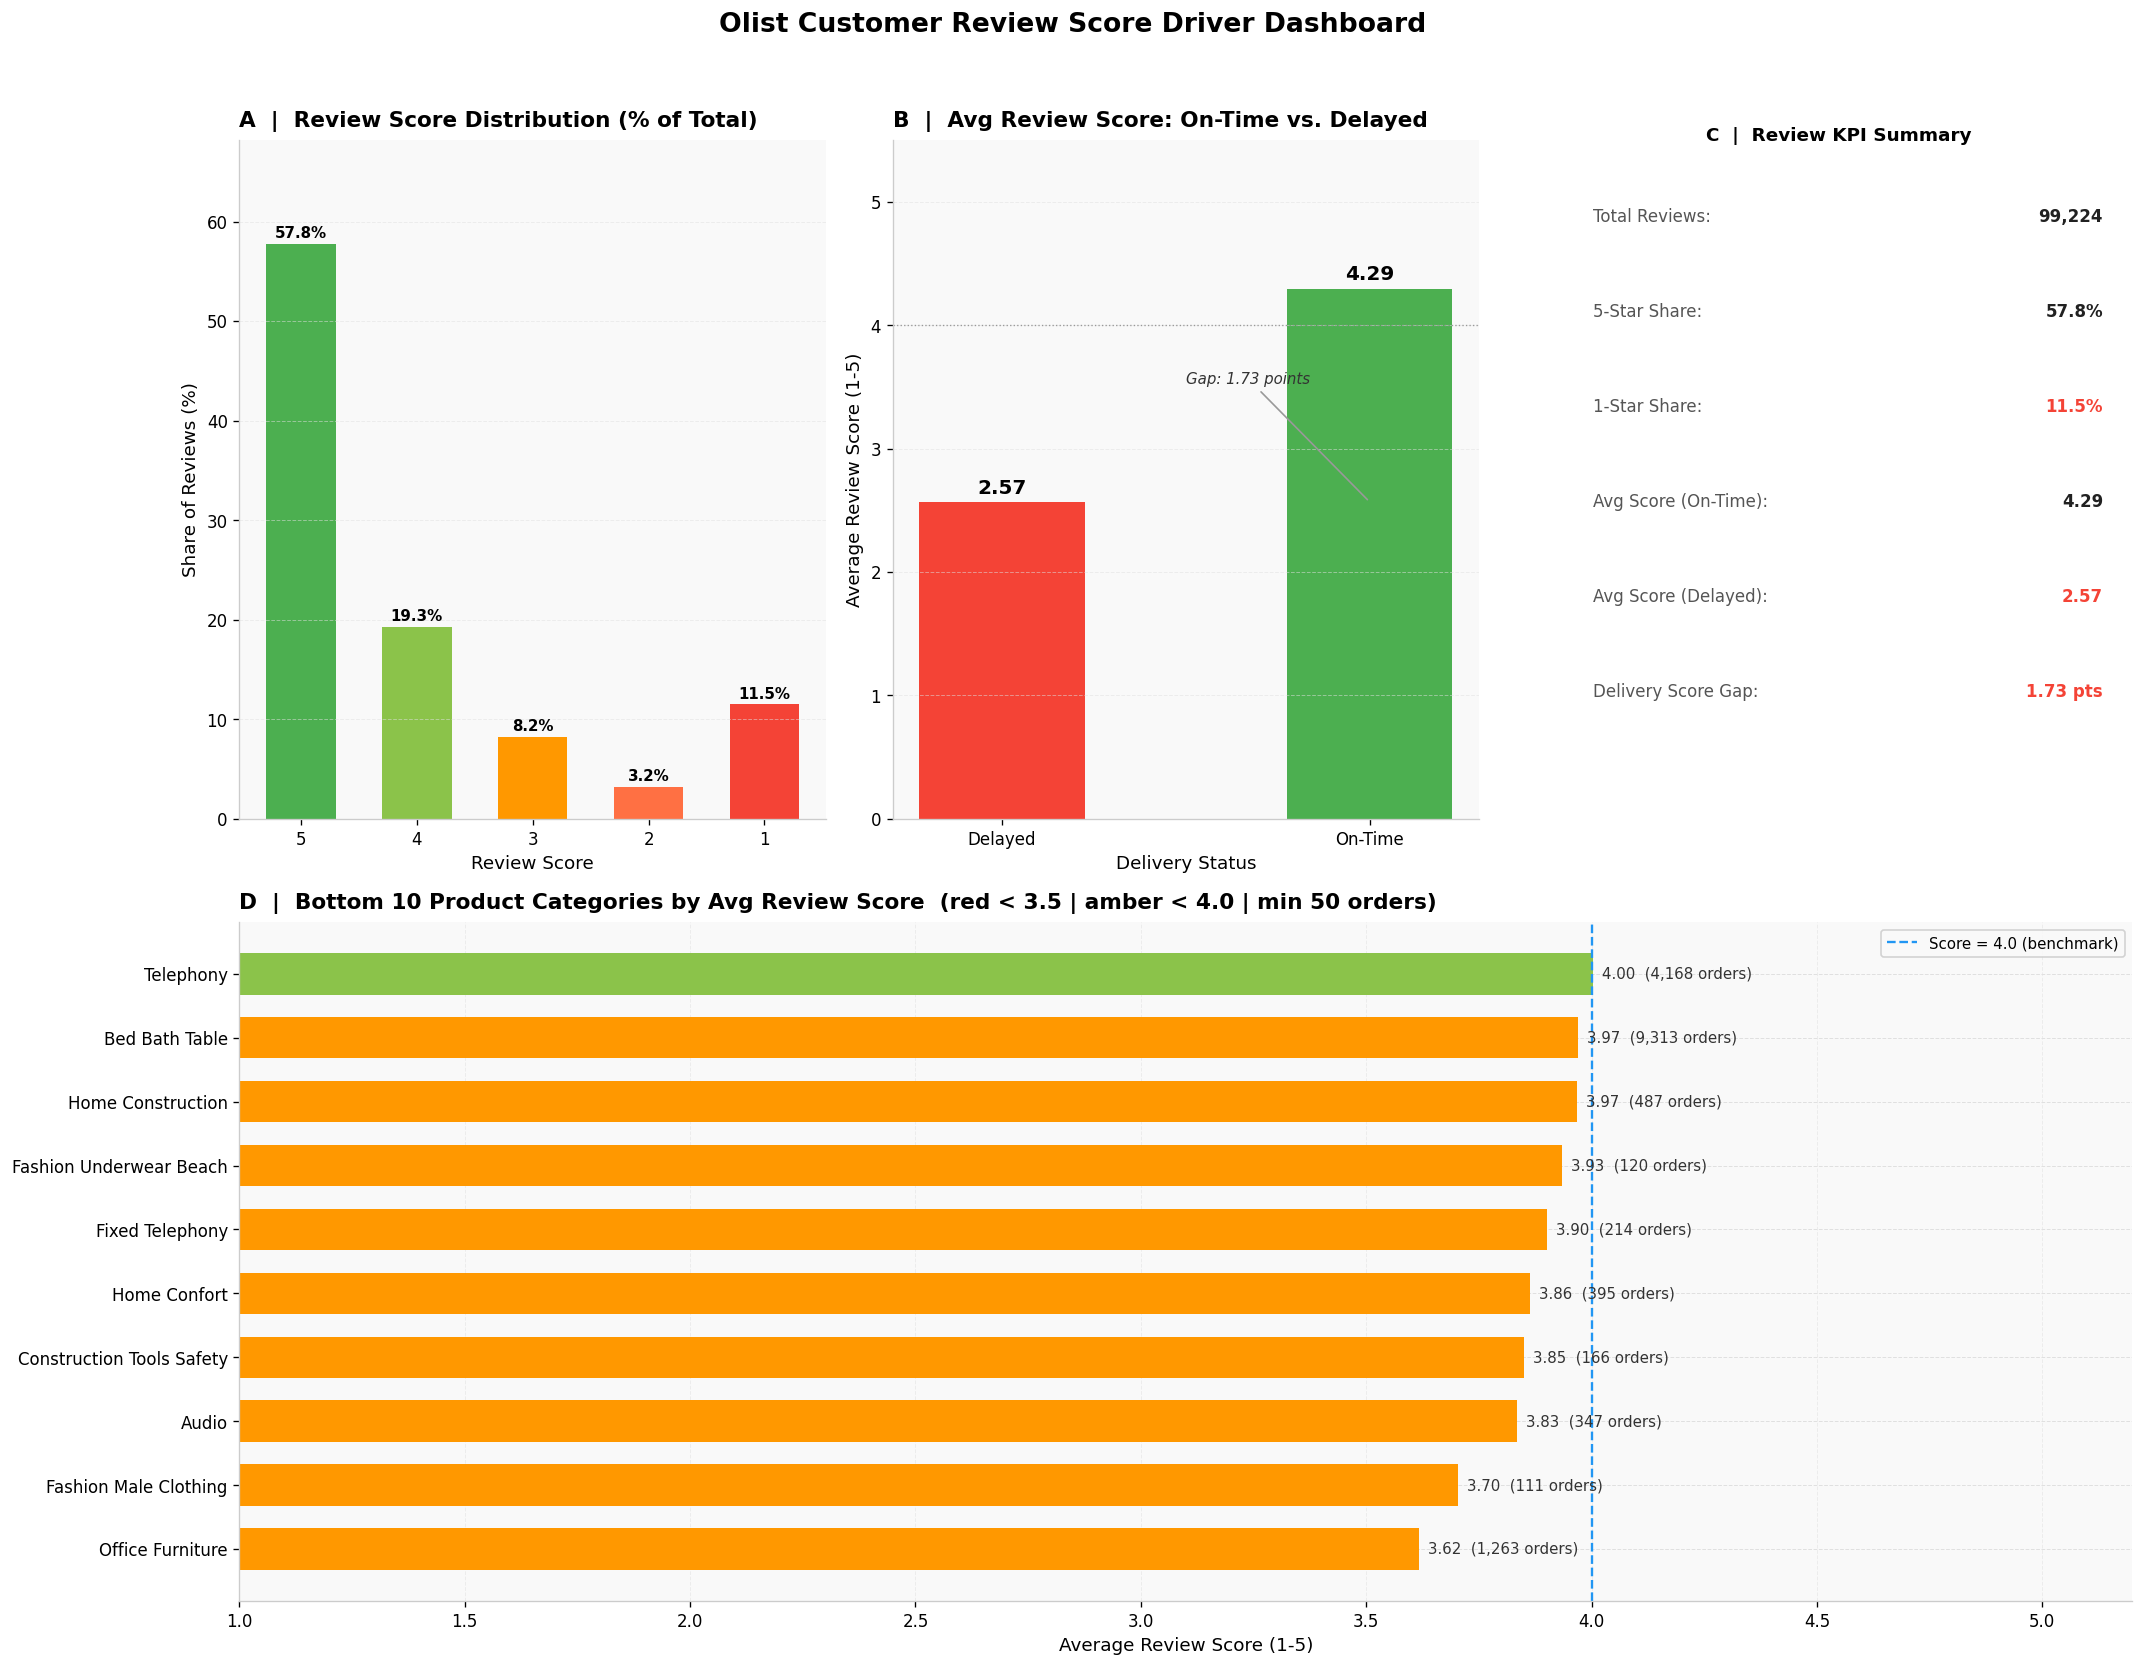

In [2]:
# =============================================================================
# Dashboard 04 — Review Score Drivers
# =============================================================================
fig = plt.figure(figsize=(18, 14))
fig.suptitle(
    "Olist Customer Review Score Driver Dashboard",
    fontsize=16, fontweight="bold", y=0.99,
)

# ---------------------------------------------------------------------------
# Derived KPIs for annotations
# ---------------------------------------------------------------------------
score_1_series = df_score_dist.loc[df_score_dist["review_score"] == 1, "pct_of_total"]
pct_1_star     = float(score_1_series.values[0]) if len(score_1_series) else 0.0

score_5_series = df_score_dist.loc[df_score_dist["review_score"] == 5, "pct_of_total"]
pct_5_star     = float(score_5_series.values[0]) if len(score_5_series) else 0.0

delivery_idx   = df_delivery_scores.set_index("delivery_status")
score_on_time  = float(delivery_idx.loc["On-Time", "avg_review_score"]) if "On-Time" in delivery_idx.index else None
score_delayed  = float(delivery_idx.loc["Delayed", "avg_review_score"]) if "Delayed" in delivery_idx.index else None

# ---------------------------------------------------------------------------
# Panel A (top-left): Score distribution bar with % labels
# ---------------------------------------------------------------------------
ax_dist = fig.add_subplot(2, 3, 1)

score_colors = {1: "#F44336", 2: "#FF7043", 3: "#FF9800", 4: "#8BC34A", 5: "#4CAF50"}
bar_colors_dist = [score_colors.get(int(s), "#9E9E9E") for s in df_score_dist["review_score"]]

bars = ax_dist.bar(
    df_score_dist["review_score"].astype(str),
    df_score_dist["pct_of_total"],
    color=bar_colors_dist, width=0.6,
)

for bar, pct in zip(bars, df_score_dist["pct_of_total"]):
    ax_dist.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{pct:.1f}%",
        ha="center", va="bottom", fontsize=9, fontweight="bold",
    )

ax_dist.set_title("A  |  Review Score Distribution (% of Total)", loc="left", pad=8)
ax_dist.set_xlabel("Review Score")
ax_dist.set_ylabel("Share of Reviews (%)")
ax_dist.set_ylim([0, df_score_dist["pct_of_total"].max() * 1.18])
ax_dist.grid(True, axis="y", linestyle="--", alpha=0.5)

# ---------------------------------------------------------------------------
# Panel B (top-centre): Delivery status vs. avg review score — gap highlighted
# ---------------------------------------------------------------------------
ax_del = fig.add_subplot(2, 3, 2)

del_colors = [
    "#4CAF50" if s == "On-Time" else "#F44336"
    for s in df_delivery_scores["delivery_status"]
]

bars_del = ax_del.bar(
    df_delivery_scores["delivery_status"],
    df_delivery_scores["avg_review_score"],
    color=del_colors, width=0.45,
)

for bar, val in zip(bars_del, df_delivery_scores["avg_review_score"]):
    ax_del.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.04,
        f"{val:.2f}",
        ha="center", va="bottom", fontsize=12, fontweight="bold",
    )

if score_on_time is not None and score_delayed is not None:
    gap = score_on_time - score_delayed
    mid_score = score_delayed + gap / 2 + 0.1
    ax_del.annotate(
        f"Gap: {gap:.2f} points",
        xy=(1, score_delayed), xytext=(0.5, mid_score),
        fontsize=9, color="#333", style="italic",
        arrowprops=dict(arrowstyle="-", color="#999"),
    )

ax_del.set_title("B  |  Avg Review Score: On-Time vs. Delayed", loc="left", pad=8)
ax_del.set_xlabel("Delivery Status")
ax_del.set_ylabel("Average Review Score (1-5)")
ax_del.set_ylim([0, 5.5])
ax_del.axhline(4.0, color="#999", linewidth=0.8, linestyle=":")
ax_del.grid(True, axis="y", linestyle="--", alpha=0.5)

# ---------------------------------------------------------------------------
# Panel C (top-right): KPI scorecard
# ---------------------------------------------------------------------------
ax_kpi = fig.add_subplot(2, 3, 3)
ax_kpi.axis("off")

total_reviews = int(df_score_dist["total_reviews"].sum())

if score_on_time is not None and score_delayed is not None:
    gap_str = f"{score_on_time - score_delayed:.2f} pts"
else:
    gap_str = "N/A"

kpi_lines = [
    ("Total Reviews",       f"{total_reviews:,}"),
    ("5-Star Share",        f"{pct_5_star:.1f}%"),
    ("1-Star Share",        f"{pct_1_star:.1f}%"),
    ("Avg Score (On-Time)", f"{score_on_time:.2f}" if score_on_time else "N/A"),
    ("Avg Score (Delayed)", f"{score_delayed:.2f}" if score_delayed else "N/A"),
    ("Delivery Score Gap",  gap_str),
]

ax_kpi.text(0.5, 1.0, "C  |  Review KPI Summary", transform=ax_kpi.transAxes,
            ha="center", fontsize=11, fontweight="bold")

y_pos = 0.88
for label, value in kpi_lines:
    is_risk = "1-Star" in label or "Delayed" in label or "Gap" in label
    ax_kpi.text(0.08, y_pos, label + ":", transform=ax_kpi.transAxes,
                ha="left", fontsize=10, color="#555")
    ax_kpi.text(0.95, y_pos, value, transform=ax_kpi.transAxes,
                ha="right", fontsize=10, fontweight="bold",
                color="#F44336" if is_risk else "#212121")
    y_pos -= 0.14

# ---------------------------------------------------------------------------
# Panel D (bottom, wide): Bottom 10 categories — horizontal bar with benchmark
# ---------------------------------------------------------------------------
ax_cat = fig.add_subplot(2, 3, (4, 6))

df_worst_sorted = df_worst_categories.sort_values("avg_review_score", ascending=True)
cat_colors = [
    "#F44336" if s < 3.5 else "#FF9800" if s < 4.0 else "#8BC34A"
    for s in df_worst_sorted["avg_review_score"]
]

bars_cat = ax_cat.barh(
    df_worst_sorted["category_english"].str.replace("_", " ").str.title(),
    df_worst_sorted["avg_review_score"],
    color=cat_colors, height=0.65,
)

for bar, (_, row) in zip(bars_cat, df_worst_sorted.iterrows()):
    label_text = f"{row['avg_review_score']:.2f}  ({int(row['total_orders']):,} orders)"
    ax_cat.text(
        row["avg_review_score"] + 0.02,
        bar.get_y() + bar.get_height() / 2,
        label_text,
        va="center", fontsize=9, color="#333",
    )

ax_cat.axvline(4.0, color="#2196F3", linewidth=1.4, linestyle="--",
               label="Score = 4.0 (benchmark)")
ax_cat.set_title(
    "D  |  Bottom 10 Product Categories by Avg Review Score  "
    "(red < 3.5 | amber < 4.0 | min 50 orders)",
    loc="left", pad=8,
)
ax_cat.set_xlabel("Average Review Score (1-5)")
ax_cat.set_xlim([1, 5.2])
ax_cat.legend(fontsize=9)
ax_cat.grid(True, axis="x", linestyle="--", alpha=0.5)
ax_cat.set_axisbelow(True)

plt.tight_layout(rect=[0, 0, 1, 0.97])
save_figure(fig, "04_review_dashboard.png")
plt.show()


# Customer Review Score Drivers Analysis — Conclusions

---

## Key Findings
- The majority of customer reviews are 5-star, but 1-star reviews represent the defining minority segment.
- Orders classified as delayed yield an average review score significantly lower than orders delivered on time.
- The average review score differential between on-time and delayed deliveries remains a persistent structural gap.
- Certain product categories consistently generate review scores materially below the platform average despite adequate order volume.
- Low-scoring categories cluster around difficult-to-ship or highly subjective product types.

## Business Implications
- The delivery delay rate operates as a direct, causal drag on overall platform customer satisfaction metrics.
- Improving logistics SLA compliance unlocks a guaranteed, measurable uplift in aggregate review scores without product-level intervention.
- Continued unmanaged exposure to consistently low-scoring categories slowly degrades aggregate brand perception and trust.

## Actionable Recommendations
- Set absolute logistics capacity limits or buffers exclusively for regions correlated with high delayed-order 1-star reviews.
- Standardize an automated escalation workflow for customer support when an active delivery breaches the estimated arrival date.
- Define a category review score floor (e.g., 3.5) and implement temporary seller suspensions for consistently breaching this threshold.
